# BDC2026 — EDA & Preprocessing Lokal VS Code

Notebook ini adalah versi **VS Code/local** dari pipeline Colab sebelumnya.

Struktur folder yang diasumsikan:

```text
C:\BDC2026
├── data
│   ├── train
│   │   ├── 0_Recyclable
│   │   ├── 1_Electronic
│   │   └── 2_Organic
│   └── test
│       └── test
├── models
├── notebooks
├── output
├── src
└── submission
```

Catatan:
- Tidak ada `drive.mount()`.
- Tidak ada ekstraksi ZIP.
- Dataset dibaca langsung dari folder lokal yang sudah diekstrak.
- Output CSV disimpan ke folder `output/preprocessing`.

## 1. Import Library dan Setup Seed

Cell ini memuat library utama untuk membaca folder gambar, membuat metadata, EDA, duplicate checking, split train-validation, dan persiapan PyTorch DataLoader.

In [36]:
from pathlib import Path
import os
import hashlib
import random
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

from sklearn.model_selection import train_test_split

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = lambda x, **kwargs: x

try:
    from IPython.display import display
except Exception:
    display = print

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_colwidth", 120)

try:
    plt.style.use("ggplot")
except Exception:
    pass

## 2. Konfigurasi Path Project Lokal

Cell ini mencari project root secara otomatis. Jadi notebook bisa dijalankan dari:
- `C:\BDC2026`
- `C:\BDC2026
otebooks`
- atau folder lain di dalam project.

Kalau auto-detect gagal, ubah manual bagian `PROJECT_ROOT = Path(r"C:\BDC2026")`.

In [37]:
# =========================
# KONFIGURASI PATH LOKAL VS CODE
# =========================

EXPECTED_CLASSES = {"0_Recyclable", "1_Electronic", "2_Organic"}
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp"}


def find_project_root(start=None):
    """
    Mencari folder project root yang memiliki data/train dan data/test.
    Ini dibuat supaya notebook tetap aman saat dijalankan dari folder notebooks/ atau root project.
    """
    if start is None:
        start = Path.cwd()

    start = Path(start).resolve()
    candidates = [start] + list(start.parents)

    for candidate in candidates:
        if (candidate / "data" / "train").exists() and (candidate / "data" / "test").exists():
            return candidate

    # Fallback khusus Windows sesuai struktur project kamu
    fallback = Path(r"C:\BDC2026")
    if (fallback / "data" / "train").exists() and (fallback / "data" / "test").exists():
        return fallback

    raise FileNotFoundError(
        "Project root tidak ditemukan. Pastikan struktur folder memiliki data/train dan data/test. "
        "Kalau perlu, set manual: PROJECT_ROOT = Path(r'C:\\BDC2026')"
    )


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
TRAIN_RAW_DIR = DATA_DIR / "train"
TEST_RAW_DIR = DATA_DIR / "test"

# Folder output lokal sesuai struktur project kamu: C:\BDC2026\output
OUTPUT_DIR = PROJECT_ROOT / "output"
EDA_OUTPUT_DIR = OUTPUT_DIR / "eda"
PREPROCESSING_OUTPUT_DIR = OUTPUT_DIR / "preprocessing"

EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PREPROCESSING_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Current working directory:", Path.cwd())
print("PROJECT_ROOT             :", PROJECT_ROOT)
print("DATA_DIR                 :", DATA_DIR)
print("TRAIN_RAW_DIR            :", TRAIN_RAW_DIR)
print("TEST_RAW_DIR             :", TEST_RAW_DIR)
print("OUTPUT_DIR               :", OUTPUT_DIR)

assert DATA_DIR.exists(), f"DATA_DIR tidak ditemukan: {DATA_DIR}"
assert TRAIN_RAW_DIR.exists(), f"TRAIN_RAW_DIR tidak ditemukan: {TRAIN_RAW_DIR}"
assert TEST_RAW_DIR.exists(), f"TEST_RAW_DIR tidak ditemukan: {TEST_RAW_DIR}"

Current working directory: c:\BDC2026\notebooks
PROJECT_ROOT             : C:\BDC2026
DATA_DIR                 : C:\BDC2026\data
TRAIN_RAW_DIR            : C:\BDC2026\data\train
TEST_RAW_DIR             : C:\BDC2026\data\test
OUTPUT_DIR               : C:\BDC2026\output


## 3. Deteksi Struktur Folder Train dan Test

Cell ini mencari:
- root train yang berisi `0_Recyclable`, `1_Electronic`, `2_Organic`
- root test yang berisi gambar test langsung

Ini penting karena folder test kamu berbentuk `data/test/test`, jadi notebook perlu menemukan folder test terdalam secara otomatis.

In [38]:
# =========================
# FUNGSI BANTUAN PATH DAN GAMBAR
# =========================

def get_all_images(root):
    root = Path(root)
    return sorted([
        p for p in root.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])


def count_images_in_dir(folder):
    return len(get_all_images(folder))


def find_train_root(root):
    """
    Mencari folder yang berisi langsung:
    0_Recyclable, 1_Electronic, 2_Organic.
    """
    root = Path(root)
    candidate_dirs = [root] + [p for p in root.rglob("*") if p.is_dir()]

    for folder in candidate_dirs:
        try:
            child_dirs = {p.name for p in folder.iterdir() if p.is_dir()}
        except Exception:
            continue

        if EXPECTED_CLASSES.issubset(child_dirs):
            return folder

    raise FileNotFoundError(
        "Tidak menemukan folder yang berisi 0_Recyclable, 1_Electronic, dan 2_Organic."
    )


def find_test_root(root):
    """
    Mencari folder test yang paling banyak berisi file gambar langsung.
    Cocok untuk struktur seperti data/test/test/*.jpg.
    """
    root = Path(root)
    candidate_dirs = [root] + [p for p in root.rglob("*") if p.is_dir()]

    best_dir = None
    best_count = 0

    for folder in candidate_dirs:
        try:
            count = sum(
                1 for p in folder.iterdir()
                if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
            )
        except Exception:
            continue

        if count > best_count:
            best_count = count
            best_dir = folder

    if best_dir is None or best_count == 0:
        raise FileNotFoundError("Tidak menemukan folder yang berisi gambar test.")

    return best_dir


TRAIN_DIR = find_train_root(TRAIN_RAW_DIR)
TEST_DIR = find_test_root(TEST_RAW_DIR)

print("TRAIN_DIR final:", TRAIN_DIR)
print("TEST_DIR final :", TEST_DIR)

TRAIN_DIR final: C:\BDC2026\data\train
TEST_DIR final : C:\BDC2026\data\test\test


## 4. Cek Jumlah Gambar Train dan Test

Checkpoint awal untuk memastikan semua folder terbaca dengan benar.

In [39]:
# =========================
# CEK JUMLAH GAMBAR
# =========================

print("Jumlah gambar train per kelas:")

train_counts = {}

for class_dir in sorted(TRAIN_DIR.iterdir()):
    if class_dir.is_dir() and class_dir.name in EXPECTED_CLASSES:
        total = count_images_in_dir(class_dir)
        train_counts[class_dir.name] = total
        print(f"{class_dir.name}: {total}")

total_train = sum(train_counts.values())
total_test = count_images_in_dir(TEST_DIR)

print("\nTotal train:", total_train)
print("Total test :", total_test)

assert total_train > 0, "Total train = 0. Ada masalah path folder train."
assert total_test > 0, "Total test = 0. Ada masalah path folder test."
assert set(train_counts.keys()) == EXPECTED_CLASSES, f"Kelas train tidak lengkap. Ditemukan: {set(train_counts.keys())}"

Jumlah gambar train per kelas:
0_Recyclable: 9999
1_Electronic: 3961
2_Organic: 12567

Total train: 26527
Total test : 1458


## 5. Buat Metadata Train dan Test

Metadata ini mengubah struktur folder gambar menjadi tabel `train_df` dan `test_df`.

Train memiliki label, sedangkan test tidak punya label.

In [40]:
# =========================
# METADATA TRAIN
# =========================

train_records = []

for class_dir in sorted(TRAIN_DIR.iterdir()):
    if not class_dir.is_dir() or class_dir.name not in EXPECTED_CLASSES:
        continue

    label_name = class_dir.name
    label_id = int(label_name.split("_")[0])

    image_paths = get_all_images(class_dir)

    for img_path in image_paths:
        train_records.append({
            "path": str(img_path),
            "filename": img_path.name,
            "label": label_id,
            "class_name": label_name,
            "relative_path": str(img_path.relative_to(PROJECT_ROOT))
        })

train_df = pd.DataFrame(train_records)

# =========================
# METADATA TEST
# =========================

test_records = []

test_image_paths = get_all_images(TEST_DIR)

for img_path in test_image_paths:
    test_records.append({
        "path": str(img_path),
        "filename": img_path.name,
        "relative_path": str(img_path.relative_to(PROJECT_ROOT))
    })

test_df = pd.DataFrame(test_records)

train_df = train_df.sort_values(["label", "filename"]).reset_index(drop=True)
test_df = test_df.sort_values("filename").reset_index(drop=True)

print("Train metadata:", train_df.shape)
print("Test metadata :", test_df.shape)

display(train_df.head())
display(test_df.head())

Train metadata: (26527, 5)
Test metadata : (1458, 3)


,path,filename,label,class_name,relative_path
0,C:\BDC2026\data\train\0_Recyclable\R_1.jpg,R_1.jpg,0,0_Recyclable,data\train\0_Recyclable\R_1.jpg
1,C:\BDC2026\data\train\0_Recyclable\R_10.jpg,R_10.jpg,0,0_Recyclable,data\train\0_Recyclable\R_10.jpg
2,C:\BDC2026\data\train\0_Recyclable\R_100.jpg,R_100.jpg,0,0_Recyclable,data\train\0_Recyclable\R_100.jpg
3,C:\BDC2026\data\train\0_Recyclable\R_1000.jpg,R_1000.jpg,0,0_Recyclable,data\train\0_Recyclable\R_1000.jpg
4,C:\BDC2026\data\train\0_Recyclable\R_1001.jpg,R_1001.jpg,0,0_Recyclable,data\train\0_Recyclable\R_1001.jpg


,path,filename,relative_path
0,C:\BDC2026\data\test\test\1.jpg,1.jpg,data\test\test\1.jpg
1,C:\BDC2026\data\test\test\10.jpg,10.jpg,data\test\test\10.jpg
2,C:\BDC2026\data\test\test\100.jpg,100.jpg,data\test\test\100.jpg
3,C:\BDC2026\data\test\test\1000.jpg,1000.jpg,data\test\test\1000.jpg
4,C:\BDC2026\data\test\test\1001.jpg,1001.jpg,data\test\test\1001.jpg


## 6. Distribusi Kelas Train

Cell ini menghitung jumlah dan persentase gambar di setiap kelas.

,label,class_name,count,percentage
0,0,0_Recyclable,9999,37.693671
1,1,1_Electronic,3961,14.931956
2,2,2_Organic,12567,47.374373


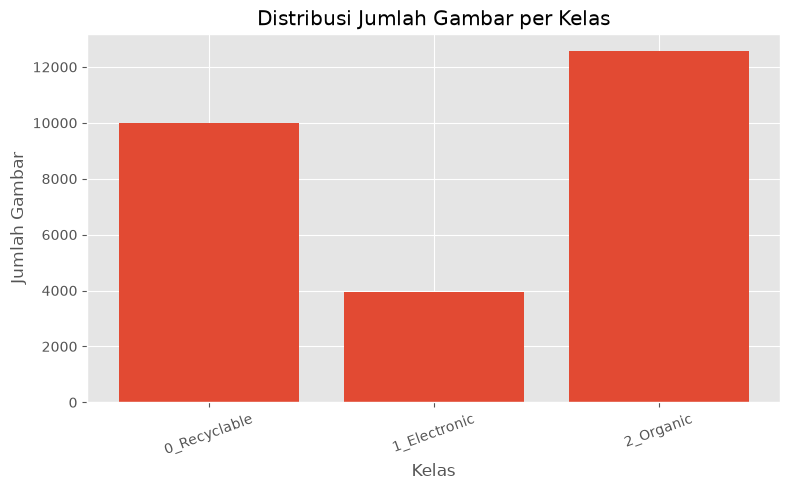

In [41]:
class_distribution = (
    train_df
    .groupby(["label", "class_name"])
    .size()
    .reset_index(name="count")
    .sort_values("label")
)

class_distribution["percentage"] = (
    class_distribution["count"] / class_distribution["count"].sum() * 100
)

display(class_distribution)

plt.figure(figsize=(8, 5))
plt.bar(class_distribution["class_name"], class_distribution["count"])
plt.title("Distribusi Jumlah Gambar per Kelas")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Simpan tabel distribusi
class_distribution.to_csv(EDA_OUTPUT_DIR / "class_distribution.csv", index=False)

## 7. Tampilkan Sample Gambar per Kelas

Cell ini menampilkan contoh gambar dari setiap kelas untuk inspeksi visual.

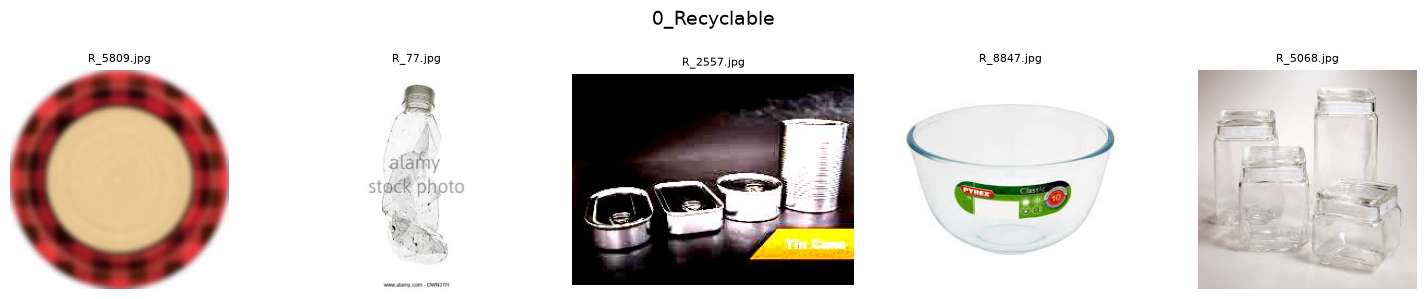

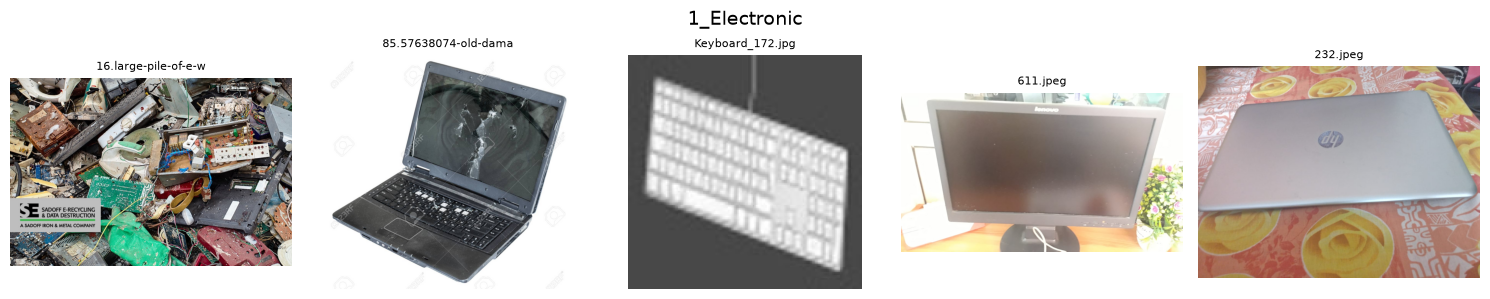

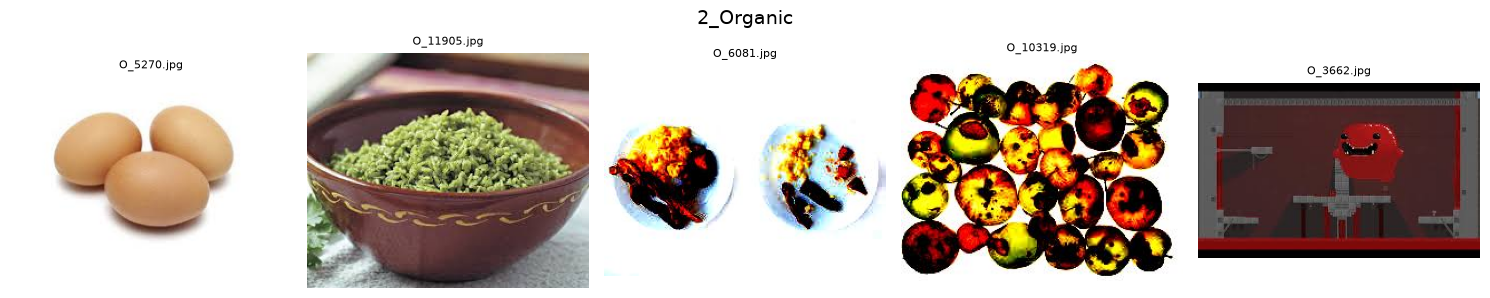

In [42]:
def show_samples_per_class(df, n=5):
    class_names = sorted(df["class_name"].unique())

    for class_name in class_names:
        class_df = df[df["class_name"] == class_name]
        n_show = min(n, len(class_df))

        sample_df = class_df.sample(n=n_show, random_state=SEED)

        plt.figure(figsize=(3 * n_show, 3))
        plt.suptitle(class_name, fontsize=14)

        for i, (_, row) in enumerate(sample_df.iterrows()):
            img = Image.open(row["path"]).convert("RGB")

            plt.subplot(1, n_show, i + 1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(row["filename"][:20], fontsize=8)

        plt.tight_layout()
        plt.show()

show_samples_per_class(train_df, n=5)

## 8. Cek Ukuran Gambar dan File Rusak

Cell ini membaca setiap gambar untuk mengecek:
- width
- height
- mode warna
- apakah file corrupt/rusak

In [43]:
def get_image_info(path):
    try:
        with Image.open(path) as img:
            width, height = img.size
            mode = img.mode

        return width, height, mode, False

    except Exception:
        return None, None, None, True

# Train image info
train_info = []
for path in tqdm(train_df["path"], desc="Cek gambar train"):
    train_info.append(get_image_info(path))

train_df["width"] = [x[0] for x in train_info]
train_df["height"] = [x[1] for x in train_info]
train_df["mode"] = [x[2] for x in train_info]
train_df["is_corrupt"] = [x[3] for x in train_info]

# Test image info
test_info = []
for path in tqdm(test_df["path"], desc="Cek gambar test"):
    test_info.append(get_image_info(path))

test_df["width"] = [x[0] for x in test_info]
test_df["height"] = [x[1] for x in test_info]
test_df["mode"] = [x[2] for x in test_info]
test_df["is_corrupt"] = [x[3] for x in test_info]

print("Corrupt train:", train_df["is_corrupt"].sum())
print("Corrupt test :", test_df["is_corrupt"].sum())

print("\nStatistik ukuran train:")
display(train_df[["width", "height"]].describe())

print("\nStatistik ukuran test:")
display(test_df[["width", "height"]].describe())

Cek gambar train:   0%|          | 0/26527 [00:00<?, ?it/s]

Cek gambar test:   0%|          | 0/1458 [00:00<?, ?it/s]

Corrupt train: 0
Corrupt test : 0

Statistik ukuran train:


,width,height
count,26527.000000,26527.000000
mean,304.941041,250.227391
std,417.923007,342.697508
min,51.000000,69.000000
25%,220.000000,174.000000
50%,254.000000,194.000000
75%,276.000000,225.000000
max,8000.000000,6000.000000



Statistik ukuran test:


,width,height
count,1458.000000,1458.000000
mean,298.199588,247.703704
std,484.581386,438.113210
min,96.000000,94.000000
25%,220.000000,168.000000
50%,235.500000,194.000000
75%,275.000000,225.000000
max,8000.000000,6000.000000


## 9. Visualisasi Distribusi Ukuran Gambar

Cell ini membuat histogram width, height, dan aspect ratio pada data train.

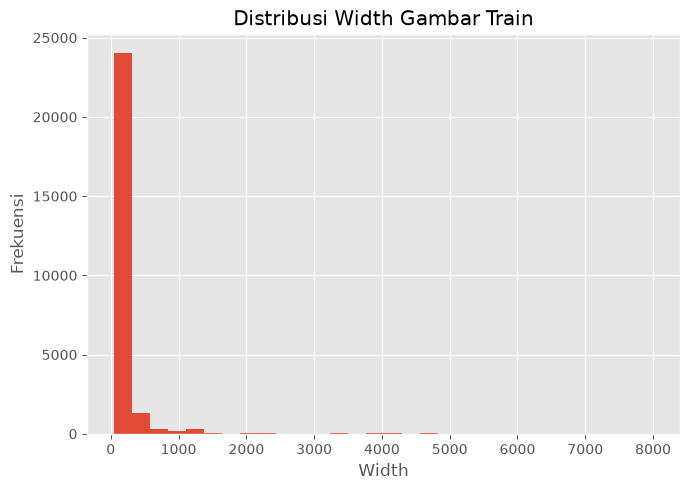

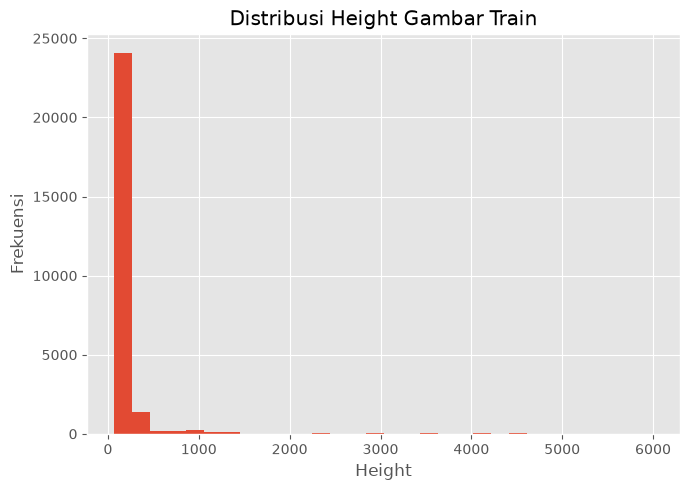

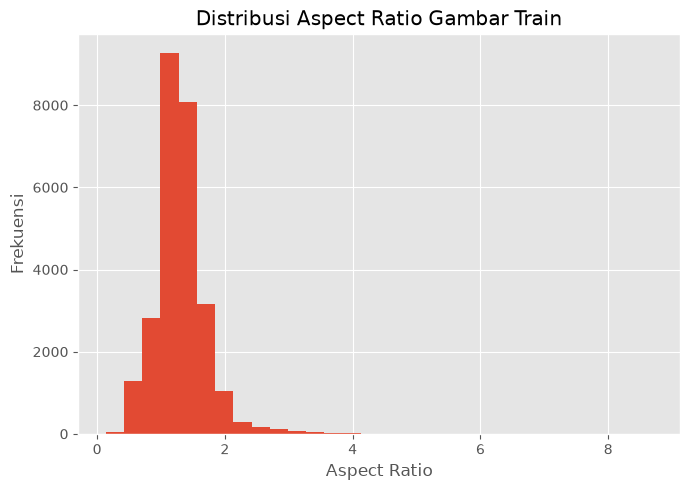

In [44]:
valid_train_size = train_df[train_df["is_corrupt"] == False].copy()
valid_test_size = test_df[test_df["is_corrupt"] == False].copy()

valid_train_size["aspect_ratio"] = valid_train_size["width"] / valid_train_size["height"]
valid_test_size["aspect_ratio"] = valid_test_size["width"] / valid_test_size["height"]

plt.figure(figsize=(7, 5))
plt.hist(valid_train_size["width"], bins=30)
plt.title("Distribusi Width Gambar Train")
plt.xlabel("Width")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(valid_train_size["height"], bins=30)
plt.title("Distribusi Height Gambar Train")
plt.xlabel("Height")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.hist(valid_train_size["aspect_ratio"], bins=30)
plt.title("Distribusi Aspect Ratio Gambar Train")
plt.xlabel("Aspect Ratio")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

## 10. Deteksi Exact Duplicate dengan MD5

MD5 digunakan sebagai sidik jari file. Jika dua gambar punya MD5 yang sama, berarti file-nya identik secara byte.

In [45]:
def calculate_md5(path, chunk_size=8192):
    hash_md5 = hashlib.md5()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            hash_md5.update(chunk)

    return hash_md5.hexdigest()

train_df["md5"] = None

valid_idx = train_df[train_df["is_corrupt"] == False].index

for idx in tqdm(valid_idx, desc="Hitung MD5 train"):
    train_df.loc[idx, "md5"] = calculate_md5(train_df.loc[idx, "path"])

duplicate_df = train_df[
    train_df["md5"].notna() & train_df.duplicated("md5", keep=False)
].copy()

duplicate_df = duplicate_df.sort_values(["md5", "label", "filename"])

print("Jumlah gambar yang terlibat duplicate:", len(duplicate_df))
print("Jumlah grup duplicate:", duplicate_df["md5"].nunique())

display(duplicate_df.head(20))

Hitung MD5 train:   0%|          | 0/26527 [00:00<?, ?it/s]

Jumlah gambar yang terlibat duplicate: 124
Jumlah grup duplicate: 62


,path,filename,label,class_name,relative_path,width,height,mode,is_corrupt,md5
8573,C:\BDC2026\data\train\0_Recyclable\R_8715.jpg,R_8715.jpg,0,0_Recyclable,data\train\0_Recyclable\R_8715.jpg,225,225,RGB,False,02b6ec5bc7c76efed16027bea19fd211
9195,C:\BDC2026\data\train\0_Recyclable\R_9275.jpg,R_9275.jpg,0,0_Recyclable,data\train\0_Recyclable\R_9275.jpg,225,225,RGB,False,02b6ec5bc7c76efed16027bea19fd211
17086,C:\BDC2026\data\train\2_Organic\O_1500.jpg,O_1500.jpg,2,2_Organic,data\train\2_Organic\O_1500.jpg,280,180,RGB,False,04063326bce08045d6a668c788cea105
20672,C:\BDC2026\data\train\2_Organic\O_473.jpg,O_473.jpg,2,2_Organic,data\train\2_Organic\O_473.jpg,280,180,RGB,False,04063326bce08045d6a668c788cea105
8318,C:\BDC2026\data\train\0_Recyclable\R_8486.jpg,R_8486.jpg,0,0_Recyclable,data\train\0_Recyclable\R_8486.jpg,225,225,RGB,False,08a364c3cede63a2273820590b06498e
9118,C:\BDC2026\data\train\0_Recyclable\R_9205.jpg,R_9205.jpg,0,0_Recyclable,data\train\0_Recyclable\R_9205.jpg,225,225,RGB,False,08a364c3cede63a2273820590b06498e
12775,C:\BDC2026\data\train\1_Electronic\Printer_63.jpg,Printer_63.jpg,1,1_Electronic,data\train\1_Electronic\Printer_63.jpg,150,150,RGB,False,0bdb9da68380941bb62cef41c49e468f
12776,C:\BDC2026\data\train\1_Electronic\Printer_64.jpg,Printer_64.jpg,1,1_Electronic,data\train\1_Electronic\Printer_64.jpg,150,150,RGB,False,0bdb9da68380941bb62cef41c49e468f
17033,C:\BDC2026\data\train\2_Organic\O_1453.jpg,O_1453.jpg,2,2_Organic,data\train\2_Organic\O_1453.jpg,225,225,RGB,False,18e0c587877ab4d9c338d9f998896ae7
19896,C:\BDC2026\data\train\2_Organic\O_403.jpg,O_403.jpg,2,2_Organic,data\train\2_Organic\O_403.jpg,225,225,RGB,False,18e0c587877ab4d9c338d9f998896ae7


## 11. Deteksi Duplicate Lintas Kelas

Duplicate lintas kelas terjadi ketika file gambar identik muncul pada dua label berbeda. Ini penting karena bisa menunjukkan konflik label.

In [46]:
cross_class_duplicates = []

for md5_hash, group in duplicate_df.groupby("md5"):
    unique_labels = group["label"].nunique()

    if unique_labels > 1:
        cross_class_duplicates.append(group)

print("Jumlah grup duplicate lintas kelas:", len(cross_class_duplicates))

if len(cross_class_duplicates) > 0:
    cross_class_df = pd.concat(cross_class_duplicates).sort_values(["md5", "label"])
    display(cross_class_df[["path", "filename", "label", "class_name", "md5"]])
else:
    cross_class_df = pd.DataFrame()
    print("Tidak ada duplicate lintas kelas.")

Jumlah grup duplicate lintas kelas: 1


,path,filename,label,class_name,md5
7766,C:\BDC2026\data\train\0_Recyclable\R_799.jpg,R_799.jpg,0,0_Recyclable,95bd2693fd68b87d40601c3002ebdf21
25275,C:\BDC2026\data\train\2_Organic\O_8873.jpg,O_8873.jpg,2,2_Organic,95bd2693fd68b87d40601c3002ebdf21


## 12. Tampilkan Duplicate Lintas Kelas

Jika ada duplicate lintas kelas, gambar akan ditampilkan berdampingan agar bisa dicek secara visual.

Duplicate lintas kelas ke-1


,path,filename,label,class_name
7766,C:\BDC2026\data\train\0_Recyclable\R_799.jpg,R_799.jpg,0,0_Recyclable
25275,C:\BDC2026\data\train\2_Organic\O_8873.jpg,O_8873.jpg,2,2_Organic


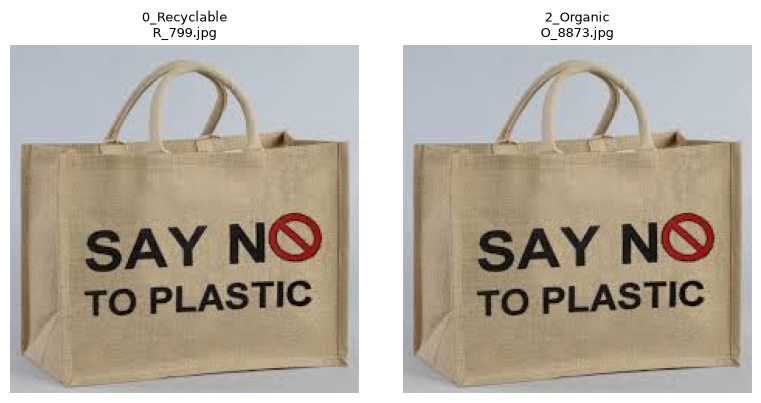

In [47]:
if len(cross_class_duplicates) > 0:
    for idx, group in enumerate(cross_class_duplicates):
        print(f"Duplicate lintas kelas ke-{idx + 1}")
        display(group[["path", "filename", "label", "class_name"]])

        n_show = len(group)
        plt.figure(figsize=(4 * n_show, 4))

        for i, (_, row) in enumerate(group.iterrows()):
            img = Image.open(row["path"]).convert("RGB")

            plt.subplot(1, n_show, i + 1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"{row['class_name']}\n{row['filename']}", fontsize=9)

        plt.tight_layout()
        plt.show()
else:
    print("Tidak ada duplicate lintas kelas untuk ditampilkan.")

In [48]:
# =========================
# CLEANING DUPLICATE LINTAS KELAS
# =========================

files_to_exclude = [
    "O_8873.jpg"
]

clean_train_df = train_df[
    (train_df["is_corrupt"] == False) &
    (~train_df["filename"].isin(files_to_exclude))
].copy()

clean_train_df = clean_train_df.reset_index(drop=True)

print("Total data sebelum cleaning:", len(train_df))
print("Total data setelah cleaning :", len(clean_train_df))
print("Jumlah data dikeluarkan    :", len(train_df) - len(clean_train_df))

print("\nFile yang dikeluarkan:")
display(train_df[train_df["filename"].isin(files_to_exclude)])

Total data sebelum cleaning: 26527
Total data setelah cleaning : 26526
Jumlah data dikeluarkan    : 1

File yang dikeluarkan:


,path,filename,label,class_name,relative_path,width,height,mode,is_corrupt,md5
25275,C:\BDC2026\data\train\2_Organic\O_8873.jpg,O_8873.jpg,2,2_Organic,data\train\2_Organic\O_8873.jpg,225,224,RGB,False,95bd2693fd68b87d40601c3002ebdf21


## 13. Split Train dan Validation

Split dibuat dengan mempertimbangkan `md5` sebagai group agar duplicate tidak bocor ke train dan validation sekaligus.

In [49]:
# =========================
# BERSIHKAN DATA CORRUPT
# =========================

clean_train_df = train_df[train_df["is_corrupt"] == False].copy()
clean_train_df = clean_train_df.reset_index(drop=True)

print("Total data train awal :", len(train_df))
print("Total data clean      :", len(clean_train_df))

# =========================
# SPLIT STRATIFIED + GROUP BY MD5
# =========================

VAL_SIZE = 0.2

try:
    from sklearn.model_selection import StratifiedGroupKFold

    n_splits = int(round(1 / VAL_SIZE))
    sgkf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=SEED
    )

    split_generator = sgkf.split(
        clean_train_df,
        y=clean_train_df["label"],
        groups=clean_train_df["md5"]
    )

    train_idx, val_idx = next(split_generator)

    train_split_df = clean_train_df.iloc[train_idx].copy().reset_index(drop=True)
    val_split_df = clean_train_df.iloc[val_idx].copy().reset_index(drop=True)

    print("Split menggunakan StratifiedGroupKFold berbasis MD5.")

except Exception as e:
    print("StratifiedGroupKFold gagal, fallback ke train_test_split biasa.")
    print("Error:", e)

    train_split_df, val_split_df = train_test_split(
        clean_train_df,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=clean_train_df["label"]
    )

    train_split_df = train_split_df.reset_index(drop=True)
    val_split_df = val_split_df.reset_index(drop=True)

print("Train split:", train_split_df.shape)
print("Val split  :", val_split_df.shape)

print("\nDistribusi train split:")
display(train_split_df["class_name"].value_counts().sort_index())

print("\nDistribusi val split:")
display(val_split_df["class_name"].value_counts().sort_index())

Total data train awal : 26527
Total data clean      : 26527
Split menggunakan StratifiedGroupKFold berbasis MD5.
Train split: (21221, 10)
Val split  : (5306, 10)

Distribusi train split:


class_name
0_Recyclable     7999
1_Electronic     3169
2_Organic       10053
Name: count, dtype: int64


Distribusi val split:


class_name
0_Recyclable    2000
1_Electronic     792
2_Organic       2514
Name: count, dtype: int64

## 14. Cek Duplicate Leakage Train-Val

Cell ini memastikan gambar duplicate tidak tersebar di train dan validation sekaligus.

In [50]:
train_md5 = set(train_split_df["md5"].dropna())
val_md5 = set(val_split_df["md5"].dropna())

leaked_md5 = train_md5.intersection(val_md5)

print("Jumlah duplicate leakage train-val:", len(leaked_md5))

if len(leaked_md5) > 0:
    leakage_train = train_split_df[train_split_df["md5"].isin(leaked_md5)]
    leakage_val = val_split_df[val_split_df["md5"].isin(leaked_md5)]

    print("Contoh data leakage di train:")
    display(leakage_train.head())

    print("Contoh data leakage di val:")
    display(leakage_val.head())
else:
    print("Tidak ada duplicate leakage antara train dan validation.")

Jumlah duplicate leakage train-val: 0
Tidak ada duplicate leakage antara train dan validation.


## 15. Simpan Metadata dan Split ke Folder Output Lokal

Hasil preprocessing disimpan ke `C:\BDC2026\output\preprocessing`.

In [51]:
# Simpan output ke folder lokal project
train_df.to_csv(PREPROCESSING_OUTPUT_DIR / "train_metadata_full.csv", index=False)
test_df.to_csv(PREPROCESSING_OUTPUT_DIR / "test_metadata.csv", index=False)

train_split_df.to_csv(PREPROCESSING_OUTPUT_DIR / "train_split.csv", index=False)
val_split_df.to_csv(PREPROCESSING_OUTPUT_DIR / "val_split.csv", index=False)

duplicate_df.to_csv(PREPROCESSING_OUTPUT_DIR / "duplicate_train.csv", index=False)

if len(cross_class_duplicates) > 0:
    cross_class_df.to_csv(PREPROCESSING_OUTPUT_DIR / "cross_class_duplicates.csv", index=False)

class_mapping = (
    train_df[["label", "class_name"]]
    .drop_duplicates()
    .sort_values("label")
    .reset_index(drop=True)
)

class_mapping.to_csv(PREPROCESSING_OUTPUT_DIR / "class_mapping.csv", index=False)

print("File berhasil disimpan ke:")
print(PREPROCESSING_OUTPUT_DIR)

print("\nIsi output:")
for p in sorted(PREPROCESSING_OUTPUT_DIR.iterdir()):
    print("-", p.name)

File berhasil disimpan ke:
C:\BDC2026\output\preprocessing

Isi output:
- class_mapping.csv
- cross_class_duplicates.csv
- duplicate_train.csv
- test_metadata.csv
- train_metadata_full.csv
- train_split.csv
- val_split.csv


## 16. Ringkasan Dataset dan Preprocessing

Ringkasan ini dipakai untuk memastikan dataset sudah siap masuk ke tahap training baseline.

In [52]:
print("RINGKASAN DATASET")
print("=" * 60)

print(f"Total train image : {len(train_df)}")
print(f"Total test image  : {len(test_df)}")

print("\nDistribusi kelas:")
display(class_distribution)

print("\nKualitas gambar:")
print("Corrupt train:", train_df["is_corrupt"].sum())
print("Corrupt test :", test_df["is_corrupt"].sum())

print("\nDuplicate:")
print("Jumlah gambar yang terlibat duplicate:", len(duplicate_df))
print("Jumlah grup duplicate:", duplicate_df["md5"].nunique())
print("Jumlah grup duplicate lintas kelas:", len(cross_class_duplicates))

print("\nSplit:")
print("Train split:", len(train_split_df))
print("Val split  :", len(val_split_df))
print("Duplicate leakage train-val:", len(leaked_md5))

print("\nOutput tersimpan di:")
print(PREPROCESSING_OUTPUT_DIR)

RINGKASAN DATASET
Total train image : 26527
Total test image  : 1458

Distribusi kelas:


,label,class_name,count,percentage
0,0,0_Recyclable,9999,37.693671
1,1,1_Electronic,3961,14.931956
2,2,2_Organic,12567,47.374373



Kualitas gambar:
Corrupt train: 0
Corrupt test : 0

Duplicate:
Jumlah gambar yang terlibat duplicate: 124
Jumlah grup duplicate: 62
Jumlah grup duplicate lintas kelas: 1

Split:
Train split: 21221
Val split  : 5306
Duplicate leakage train-val: 0

Output tersimpan di:
C:\BDC2026\output\preprocessing


In [53]:
# ============================================================
# CLEANING FINAL: HAPUS LABEL CONFLICT DUPLICATE LINTAS KELAS
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold, train_test_split

# File konflik label:
# 0_Recyclable/R_799.jpg  -> dipertahankan
# 2_Organic/O_8873.jpg    -> dikeluarkan dari metadata training

conflict_mask = (
    (train_df["class_name"] == "2_Organic") &
    (train_df["filename"] == "O_8873.jpg")
)

excluded_conflict_df = train_df[conflict_mask].copy()

clean_train_df = train_df[
    (train_df["is_corrupt"] == False) &
    (~conflict_mask)
].copy()

clean_train_df = clean_train_df.reset_index(drop=True)

print("Total data train awal      :", len(train_df))
print("Total data setelah cleaning:", len(clean_train_df))
print("Jumlah data dikeluarkan    :", len(train_df) - len(clean_train_df))

print("\nData yang dikeluarkan:")
display(excluded_conflict_df[["path", "filename", "label", "class_name", "md5"]])

Total data train awal      : 26527
Total data setelah cleaning: 26526
Jumlah data dikeluarkan    : 1

Data yang dikeluarkan:


,path,filename,label,class_name,md5
25275,C:\BDC2026\data\train\2_Organic\O_8873.jpg,O_8873.jpg,2,2_Organic,95bd2693fd68b87d40601c3002ebdf21


In [54]:
# ============================================================
# CEK ULANG DUPLICATE LINTAS KELAS SETELAH CLEANING
# ============================================================

duplicate_clean_df = clean_train_df[
    clean_train_df["md5"].notna() &
    clean_train_df.duplicated("md5", keep=False)
].copy()

cross_class_clean_duplicates = []

for md5_hash, group in duplicate_clean_df.groupby("md5"):
    if group["label"].nunique() > 1:
        cross_class_clean_duplicates.append(group)

print("Jumlah grup duplicate setelah cleaning:", duplicate_clean_df["md5"].nunique())
print("Jumlah grup duplicate lintas kelas setelah cleaning:", len(cross_class_clean_duplicates))

if len(cross_class_clean_duplicates) > 0:
    cross_class_clean_df = pd.concat(cross_class_clean_duplicates)
    display(cross_class_clean_df[["path", "filename", "label", "class_name", "md5"]])
else:
    print("Aman. Tidak ada duplicate lintas kelas lagi.")

Jumlah grup duplicate setelah cleaning: 61
Jumlah grup duplicate lintas kelas setelah cleaning: 0
Aman. Tidak ada duplicate lintas kelas lagi.


In [55]:
# ============================================================
# SPLIT ULANG TRAIN-VALIDATION DARI DATA CLEAN
# ============================================================

VAL_SIZE = 0.2

try:
    n_splits = int(round(1 / VAL_SIZE))

    sgkf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=SEED
    )

    split_generator = sgkf.split(
        clean_train_df,
        y=clean_train_df["label"],
        groups=clean_train_df["md5"]
    )

    train_idx, val_idx = next(split_generator)

    train_split_clean_df = clean_train_df.iloc[train_idx].copy().reset_index(drop=True)
    val_split_clean_df = clean_train_df.iloc[val_idx].copy().reset_index(drop=True)

    print("Split clean menggunakan StratifiedGroupKFold berbasis MD5.")

except Exception as e:
    print("StratifiedGroupKFold gagal, fallback ke train_test_split biasa.")
    print("Error:", e)

    train_split_clean_df, val_split_clean_df = train_test_split(
        clean_train_df,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=clean_train_df["label"]
    )

    train_split_clean_df = train_split_clean_df.reset_index(drop=True)
    val_split_clean_df = val_split_clean_df.reset_index(drop=True)

print("Train split clean:", train_split_clean_df.shape)
print("Val split clean  :", val_split_clean_df.shape)

print("\nDistribusi train split clean:")
display(train_split_clean_df["class_name"].value_counts().sort_index())

print("\nDistribusi val split clean:")
display(val_split_clean_df["class_name"].value_counts().sort_index())

Split clean menggunakan StratifiedGroupKFold berbasis MD5.
Train split clean: (21220, 10)
Val split clean  : (5306, 10)

Distribusi train split clean:


class_name
0_Recyclable     7999
1_Electronic     3169
2_Organic       10052
Name: count, dtype: int64


Distribusi val split clean:


class_name
0_Recyclable    2000
1_Electronic     792
2_Organic       2514
Name: count, dtype: int64

In [56]:
# ============================================================
# CEK LEAKAGE SETELAH CLEANING
# ============================================================

train_md5_clean = set(train_split_clean_df["md5"].dropna())
val_md5_clean = set(val_split_clean_df["md5"].dropna())

leaked_md5_clean = train_md5_clean.intersection(val_md5_clean)

print("Duplicate leakage train-val setelah cleaning:", len(leaked_md5_clean))

if len(leaked_md5_clean) > 0:
    leakage_train_clean = train_split_clean_df[train_split_clean_df["md5"].isin(leaked_md5_clean)]
    leakage_val_clean = val_split_clean_df[val_split_clean_df["md5"].isin(leaked_md5_clean)]

    print("Contoh leakage train:")
    display(leakage_train_clean.head())

    print("Contoh leakage val:")
    display(leakage_val_clean.head())
else:
    print("Aman. Tidak ada duplicate leakage train-val setelah cleaning.")

Duplicate leakage train-val setelah cleaning: 0
Aman. Tidak ada duplicate leakage train-val setelah cleaning.


In [57]:
# ============================================================
# SIMPAN OUTPUT CLEAN
# ============================================================

clean_train_df.to_csv(
    PREPROCESSING_OUTPUT_DIR / "train_metadata_clean.csv",
    index=False
)

train_split_clean_df.to_csv(
    PREPROCESSING_OUTPUT_DIR / "train_split_clean.csv",
    index=False
)

val_split_clean_df.to_csv(
    PREPROCESSING_OUTPUT_DIR / "val_split_clean.csv",
    index=False
)

excluded_conflict_df.to_csv(
    PREPROCESSING_OUTPUT_DIR / "excluded_label_conflicts.csv",
    index=False
)

print("File clean berhasil disimpan ke:")
print(PREPROCESSING_OUTPUT_DIR)

print("\nIsi output preprocessing sekarang:")
for p in sorted(PREPROCESSING_OUTPUT_DIR.iterdir()):
    print("-", p.name)

File clean berhasil disimpan ke:
C:\BDC2026\output\preprocessing

Isi output preprocessing sekarang:
- class_mapping.csv
- cross_class_duplicates.csv
- duplicate_train.csv
- excluded_label_conflicts.csv
- test_metadata.csv
- train_metadata_clean.csv
- train_metadata_full.csv
- train_split.csv
- train_split_clean.csv
- val_split.csv
- val_split_clean.csv


## 17. Optional — PyTorch Dataset dan DataLoader

Jalankan bagian ini kalau sudah mau lanjut ke notebook training baseline.

Catatan untuk Windows/VS Code:
- Kalau DataLoader terasa error/lambat, ubah `NUM_WORKERS = 0`.
- Untuk Colab/Linux biasanya `num_workers=2` aman, tapi di Windows kadang lebih stabil `0`.

In [58]:
try:
    import torch
    from torch.utils.data import Dataset, DataLoader
    from torchvision import transforms

    class WasteImageDataset(Dataset):
        def __init__(self, dataframe, transform=None, is_test=False):
            self.dataframe = dataframe.reset_index(drop=True)
            self.transform = transform
            self.is_test = is_test

        def __len__(self):
            return len(self.dataframe)

        def __getitem__(self, idx):
            row = self.dataframe.iloc[idx]

            image = Image.open(row["path"]).convert("RGB")

            if self.transform:
                image = self.transform(image)

            if self.is_test:
                return image, row["filename"]

            label = int(row["label"])
            return image, label

    IMG_SIZE = 224
    BATCH_SIZE = 32
    NUM_WORKERS = 0  # Windows/VS Code lebih stabil pakai 0

    train_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.15
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    eval_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])

    train_dataset = WasteImageDataset(train_split_df, transform=train_transform)
    val_dataset = WasteImageDataset(val_split_df, transform=eval_transform)
    test_dataset = WasteImageDataset(
        test_df[test_df["is_corrupt"] == False].copy(),
        transform=eval_transform,
        is_test=True
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available()
    )

    print("Train batches:", len(train_loader))
    print("Val batches  :", len(val_loader))
    print("Test batches :", len(test_loader))

    images, labels = next(iter(train_loader))
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

except ImportError as e:
    print("PyTorch/torchvision belum terpasang di environment ini.")
    print("Install dulu jika ingin lanjut training:")
    print("pip install torch torchvision")
    print("Error:", e)

Train batches: 664
Val batches  : 166
Test batches : 46
Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])


## Catatan Lanjutan

Jika notebook ini berhasil sampai akhir, file penting yang harus ada di:

```text
C:\BDC2026\output\preprocessing
```

adalah:

```text
train_metadata_full.csv
test_metadata.csv
train_split.csv
val_split.csv
duplicate_train.csv
class_mapping.csv
```

Setelah itu tahap berikutnya adalah membuat notebook training baseline, misalnya:

```text
notebooks/03_Baseline_Training.ipynb
```

In [1]:
print("coba")

coba
